In [1]:
import sys
from pathlib import Path
import os
parent_folder = Path(os.getcwd()).parent  # parent of current folder
sys.path.insert(0, str(parent_folder))

import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'


from TorchPropagator import WFS

from MaskGeneration import MaskVisualizator, MaskManager
from mmengine import Config
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

from scipy.io import loadmat

In [178]:
papyrus_iMat = np.load("../Data/Papyrus_iMat.npy")
reference_frame = torch.from_numpy(loadmat('../Data/referenceFrame_20250604_0306')['referenceFrame']).to(device = device, dtype = torch.float32)
reference_frame = reference_frame.view(240,240)
reference_frame /= reference_frame.sum()

M2C = torch.from_numpy(loadmat('../dm_models/M2C_KL_OOPAO_synthetic_IF')["M2C_KL"]).to(device = device, dtype = torch.float32)
papyrus_dm = torch.from_numpy(np.load("../dm_models/papyrus_dm.npy").astype(np.float32)).to(device=device) * 0.9e7

papyrus_modal_dm = (papyrus_dm @ M2C).view(80,80,-1).permute(2,0,1)
papyrus_zonal_dm = papyrus_dm.view(80,80,-1).permute(2,0,1)


valid_pix = np.std(papyrus_iMat, axis = 0)
valid_pix = valid_pix > np.median(valid_pix)*5

valid_pix = torch.from_numpy(valid_pix).to(device = device, dtype=torch.float32)
papyrus_iMat = torch.from_numpy(papyrus_iMat.astype(np.float32)).to(device = device, dtype=torch.float32)

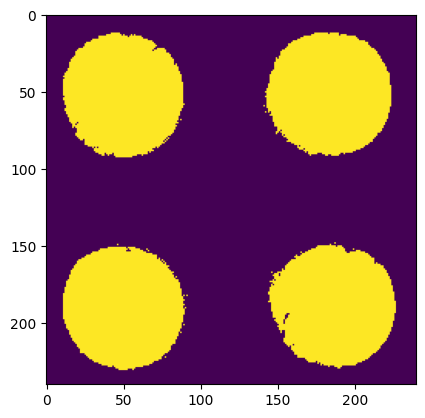

In [35]:
plt.imshow(valid_pix.cpu())

In [167]:
WFSParams = {"Nres":80,
             "sampling":240/80,
             "D": 1.52,
             "useNoise": False,
             "Modulation": 2.5,
             "MaskType": "Pyramid",
             "InitParam": [0, 0],
             "Use_MTF": False,
             "MTF_upscale": 0,
             "beamSplitProportionForWFSDetector": 0
             }


wfs = WFS(WFSParams, device)

maskManager = MaskManager(WFSParams, device, wfs)
maskManager.update_masks()

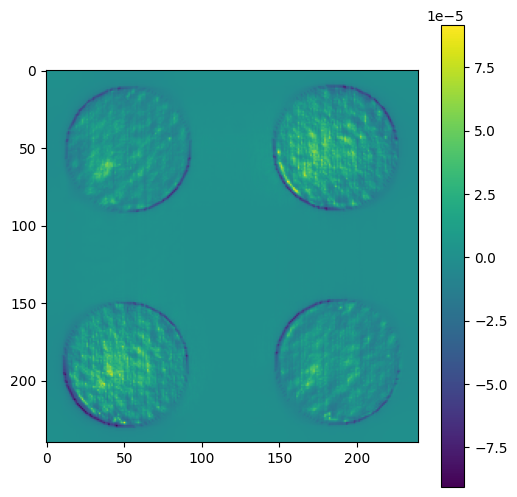

In [212]:
"""
Trains the MaskGenerator neural network to match a target mask pattern.
Generates live plots and saves intermediate mask states into a GIF.

Args:
    maskGenerator (nn.Module): Neural network to generate the mask.
    uv_coords (Tensor): 2D coordinates input to the mask generator.
    mask (Tensor): Target mask used for loss computation.
    loss (function): Loss function to optimize.
    TrainRunNb (int): Number of training iterations.
    optimizer (torch.optim.Optimizer): Optimizer used for training.
    device (str): Device for computation.

Returns:
    None
"""
final_train_loss = 0

TrainRunNb = 200
loss = torch.nn.MSELoss()

fig,ax = plt.subplots(figsize = (6,6))


img = ax.imshow(valid_pix.cpu().detach().numpy())
fig.colorbar(img)
plt.show()

optimizer = torch.optim.AdamW(maskManager.parameters(), 1e-3, fused = True)
maskManager.train()

for u in range(0,TrainRunNb) :
    

    optimizer.zero_grad()
    
    maskManager.update_masks()

    wfs.BuildReferenceIntensity() 

    digital_image = wfs.reference_intensity * 1e5
    

    l = loss(reference_frame * 1e5,digital_image)

    l. backward()
    
    optimizer.step()
    
    if u % 10 == 0:
        clear_output(wait=True)
        img.set_data((reference_frame - wfs.reference_intensity).cpu().detach().numpy())
        img.set_clim(vmin=np.min(img.get_array()), vmax=np.max(img.get_array()))
        display(fig, clear=True)
        plt.pause(0.1)
    



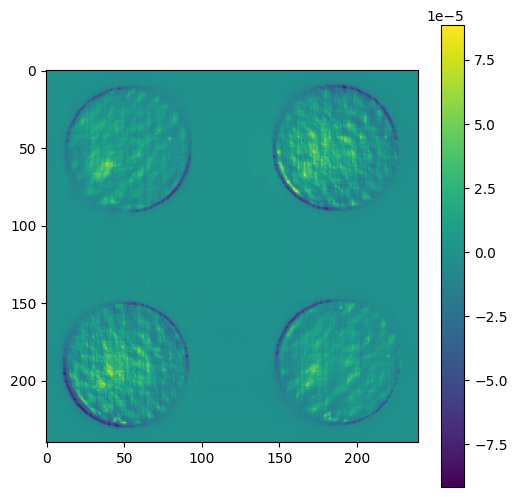

In [213]:
"""
Trains the MaskGenerator neural network to match a target mask pattern.
Generates live plots and saves intermediate mask states into a GIF.

Args:
    maskGenerator (nn.Module): Neural network to generate the mask.
    uv_coords (Tensor): 2D coordinates input to the mask generator.
    mask (Tensor): Target mask used for loss computation.
    loss (function): Loss function to optimize.
    TrainRunNb (int): Number of training iterations.
    optimizer (torch.optim.Optimizer): Optimizer used for training.
    device (str): Device for computation.

Returns:
    None
"""
final_train_loss = 0

TrainRunNb = 200
loss = torch.nn.MSELoss()

fig,ax = plt.subplots(figsize = (6,6))


img = ax.imshow(reference_frame.cpu().detach().numpy())
fig.colorbar(img)
plt.show()

optimizer = torch.optim.AdamW([maskManager.rooftop], 1e-2, fused = True)
maskManager.train()

bench_quadrants = reference_frame.view(2,120,2,120).permute(0,2,1,3)
bench_quadrants = bench_quadrants.sum(dim = (-2,-1))



for u in range(0,TrainRunNb) :
    

    optimizer.zero_grad()
    
    maskManager.update_masks()

    wfs.BuildReferenceIntensity() 

    digital_image = wfs.reference_intensity
    digital_quadrants = digital_image.view(2,120,2,120).permute(0,2,1,3)
    digital_quadrants = digital_quadrants.sum(dim = (-2,-1))
    
    l = loss(bench_quadrants,digital_quadrants)

    l. backward()
    
    optimizer.step()
    
    if u % 10 == 0:
        clear_output(wait=True)
        img.set_data((reference_frame - digital_image).cpu().detach().numpy())
        img.set_clim(vmin=np.min(img.get_array()), vmax=np.max(img.get_array()))
        display(fig, clear=True)
        plt.pause(0.1)
    



In [218]:
ref_phase = torch.nn.Parameter(torch.zeros(*wfs.pupil.shape, device = device, dtype = torch.float32))
ref_pupil = torch.nn.Parameter(torch.ones(*wfs.pupil.shape, device = device, dtype = torch.float32))

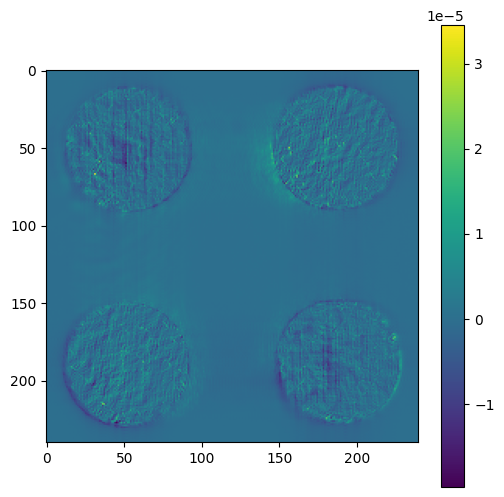

In [223]:
"""
Trains the MaskGenerator neural network to match a target mask pattern.
Generates live plots and saves intermediate mask states into a GIF.

Args:
    maskGenerator (nn.Module): Neural network to generate the mask.
    uv_coords (Tensor): 2D coordinates input to the mask generator.
    mask (Tensor): Target mask used for loss computation.
    loss (function): Loss function to optimize.
    TrainRunNb (int): Number of training iterations.
    optimizer (torch.optim.Optimizer): Optimizer used for training.
    device (str): Device for computation.

Returns:
    None
"""
final_train_loss = 0

TrainRunNb = 500
loss = torch.nn.MSELoss()

fig,ax = plt.subplots(figsize = (6,6))


img = ax.imshow(valid_pix.cpu().detach().numpy())
fig.colorbar(img)
plt.show()



optimizer = torch.optim.AdamW([ref_phase, ref_pupil], 1e-3, fused = True)
maskManager.train()

for u in range(0,TrainRunNb) :
    

    optimizer.zero_grad()
    
    maskManager.update_masks()

    digital_image = wfs.Propagator(ref_phase, ref_pupil * wfs.pupil).squeeze() * 1e5


    l = loss(reference_frame * 1e5,digital_image)

    l. backward()
    
    optimizer.step()
    
    if u % 10 == 0:
        clear_output(wait=True)
        img.set_data((reference_frame - digital_image * 1e-5).cpu().detach().numpy())
        img.set_clim(vmin=np.min(img.get_array()), vmax=np.max(img.get_array()))
        display(fig, clear=True)
        plt.pause(0.1)
    



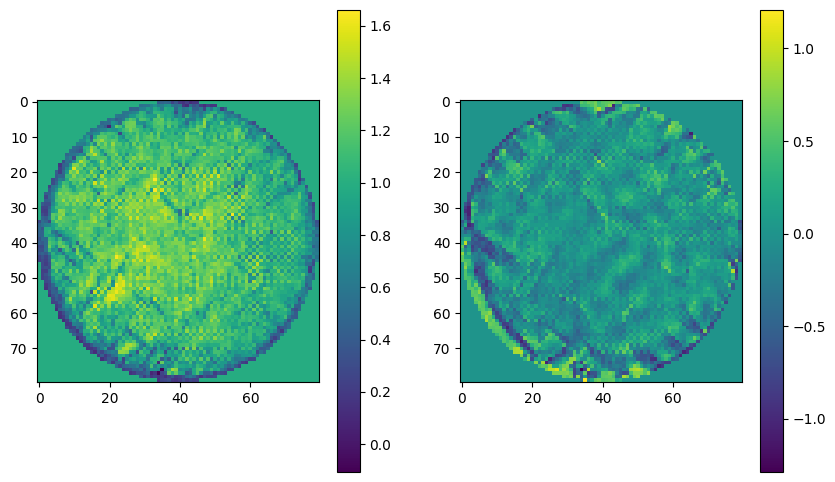

In [239]:
plt.figure(figsize=(10,6))
plt.subplot(121)
plt.imshow(ref_pupil.cpu().detach())
plt.colorbar()
plt.subplot(122)
plt.imshow(ref_phase.cpu().detach())
plt.colorbar()

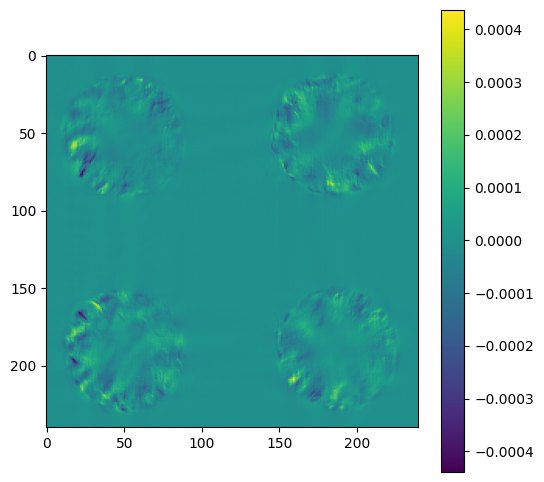

In [232]:
index = list(range(0,100,5))
TrainRunNb = 100

optimizer = torch.optim.AdamW([
    {"params": [ref_phase, ref_pupil], "lr": 1e-3},
    {"params": maskManager.parameters(), "lr": 1e-3},
], fused=True)

for u in range(0,TrainRunNb) :

    optimizer.zero_grad()
    
    maskManager.update_masks()

    wfs.BuildReconstructionMatrix(papyrus_modal_dm[index], pupil = ref_pupil, batch_size=30, phaseOffset=ref_phase)# , (papyrus_zonal_dm  * dm_flat).sum(dim = 0))

    digital_image = wfs.iMat.view(-1,240, 240)
    

    l = loss(papyrus_iMat[index],digital_image)*1e10

    l. backward() 
    
    optimizer.step()
    
    if u % 10 == 0:
        clear_output(wait=True)
        img.set_data((papyrus_iMat[index] - digital_image)[5].cpu().detach().numpy())
        img.set_clim(vmin=np.min(img.get_array()), vmax=np.max(img.get_array()))
        display(fig, clear=True)
        plt.pause(0.1)
    
torch.cuda.empty_cache()

In [233]:
with torch.no_grad():
    wfs.BuildReconstructionMatrix(papyrus_modal_dm, pupil = ref_pupil, batch_size=30, phaseOffset=ref_phase)

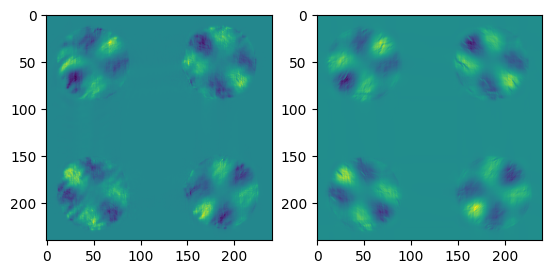

In [234]:
idx = 10
plt.subplot(121)
plt.imshow((papyrus_iMat)[idx].cpu().detach().numpy())
plt.subplot(122)
plt.imshow((wfs.iMat)[idx].view(240, 240).cpu().detach().numpy())

In [235]:
with torch.no_grad():
    cov = papyrus_iMat.view(195,-1) @ torch.linalg.pinv(wfs.iMat)

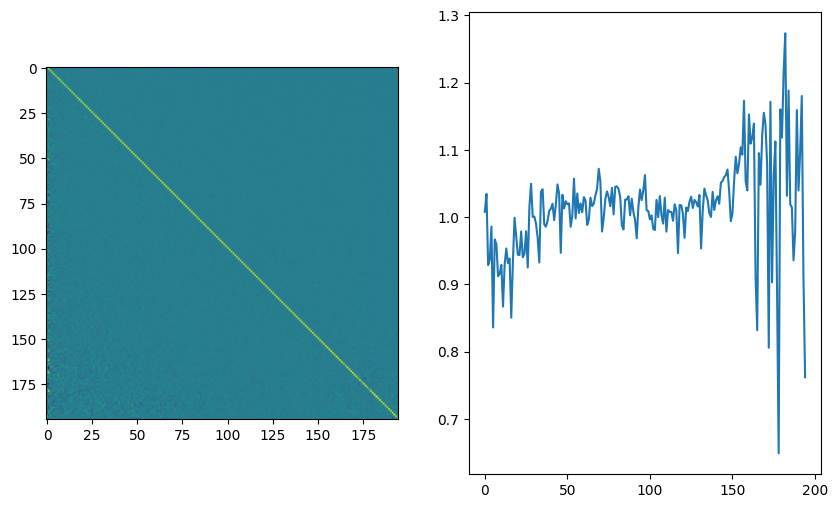

In [236]:
plt.figure(figsize=(10,6))
plt.subplot(121)
plt.imshow(cov.cpu().detach())
plt.subplot(122)
plt.plot(torch.diag(cov).cpu().detach())

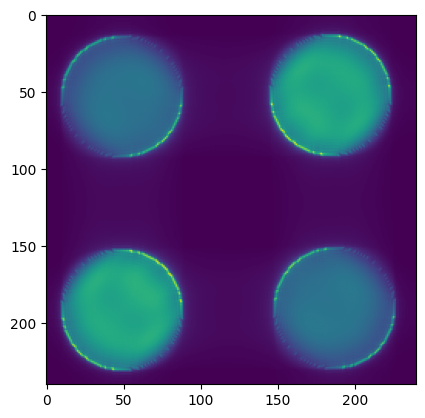

In [166]:
wfs.BuildReferenceIntensity()
plt.imshow(wfs.reference_intensity.cpu().detach())